Assignment: Analysing Purchasing Patterns for Strategic Business
Insights

Objective:
A retail company is looking to understand its customer’s purchasing behavior and
demographic trends. The company has provided two datasets: purchase data (containing
information about orders) and customer data (containing customer demographic details).
The goal is to derive actionable insights from these datasets.
You are tasked with analysing these datasets to answer key business questions and provide
recommendations.


Problem Statement:
The company wants to address the following business questions:
1. Which products contribute the most to revenue, and how can discounts and shipping
costs be optimised?
2. Are there any patterns in customer demographics (age, income, and country) that
influence purchasing behavior?
3. Is there a significant difference in income or purchasing habits between genders?
4. Can the shipping process be optimized by analysing shipping costs and durations?
5. How strongly does customer income correlate with their purchasing behavior?

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# load the dataset
purchase = pd.read_csv("C:/Users/Shivangi/Downloads/purchase.csv")
purchase.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022


In [100]:
customer= pd.read_csv("C:/Users/Shivangi/Downloads/customer.csv")
customer

,customer_id,first_name,last_name,gender,age,country,income
0,CS00001,Isadora,Porto,Female,19,Brazil,117196
1,CS00002,Hugo,Carreño,Male,33,Chile,49256
2,CS00003,René,Olivera,Male,65,Mexico,33434
3,CS00004,Luiz Henrique,Pinto,Male,55,Brazil,75302
4,CS00005,Leonardo,Monteiro,Male,19,Brazil,32280
...,...,...,...,...,...,...,...
996,CS00997,Alana,Fogaça,Female,50,Brazil,117708
997,CS00998,María,Fuenzalida,Female,21,Chile,32803
998,CS00999,Nelson,Rueda,Male,32,Colombia,129926
999,CS01000,Isabella,Ribeiro,Female,39,Brazil,99320


Task 1: Revenue Analysis
1. Calculate the total revenue for each product by combining price, discount, quantity,
and tax. Provide a list of the top 5 products that contribute the most to total revenue.
2. Visualise the contribution of these top 5 products using a bar chart.


In [101]:
#1. Calculate the total revenue for each product by combining price, discount, quantity, and tax. Provide a list of the top 5 products that contribute the most to total revenue.
# calcualte revenue per product
purchase['revenue'] = (purchase['price'] - purchase['discount'] + purchase['tax']) * purchase['quantity']

In [102]:
purchase.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,revenue
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020,5806.53
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022,259.83
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021,10608.96
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020,684.39
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022,12496.75


In [103]:
purchase.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,revenue
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020,5806.53
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022,259.83
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021,10608.96
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020,684.39
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022,12496.75


In [104]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       50000 non-null  object 
 1   customer_id    50000 non-null  object 
 2   product_name   50000 non-null  object 
 3   description    50000 non-null  object 
 4   price          50000 non-null  float64
 5   discount       50000 non-null  float64
 6   tax            50000 non-null  float64
 7   order_date     50000 non-null  object 
 8   quantity       50000 non-null  int64  
 9   shipping_cost  50000 non-null  float64
 10  shipping_date  50000 non-null  object 
 11  revenue        50000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 4.6+ MB


In [105]:
# sort the value
top_five = purchase.sort_values(by='revenue', ascending=False)[['product_name', 'revenue']]
top_five.head()

,product_name,revenue
3495,Rugs,49973.8
46463,Kitchen Appliances,49927.2
35118,Home Decor,49915.7
10934,Curtains,49898.9
32327,Kitchen Appliances,49884.2


In [106]:
# sort and find top 5 revenue
top_five= purchase.sort_values(by='revenue',ascending=False)[['product_name','revenue']].head(5)
top_five

,product_name,revenue
3495,Rugs,49973.8
46463,Kitchen Appliances,49927.2
35118,Home Decor,49915.7
10934,Curtains,49898.9
32327,Kitchen Appliances,49884.2


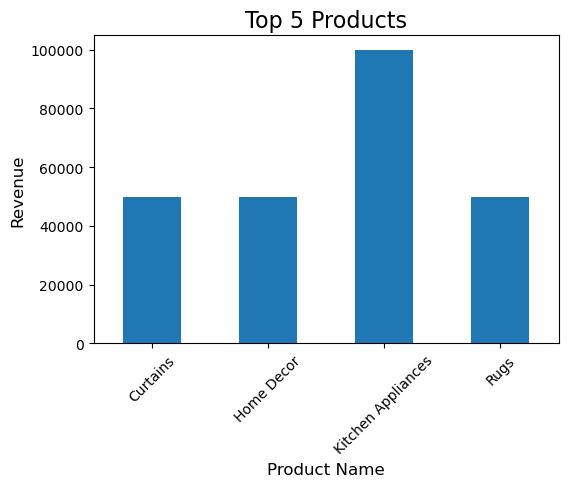

In [107]:
#2. Visualise the contribution of these top 5 products using a bar chart.

top_five_contribution = top_five.groupby('product_name')['revenue'].sum()

plt.figure(figsize=(6, 4))
top_five_contribution.plot(kind='bar')
plt.title("Top 5 Products", fontsize=16)
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.show()


#Task 2: Customer Segmentation
1. Visualise the distribution of customers by age groups using a histogram or pie chart.
 
2 Identify the countries with the highest number of customers and visualize the distribution of customers across countries using a horizontal bar chart.

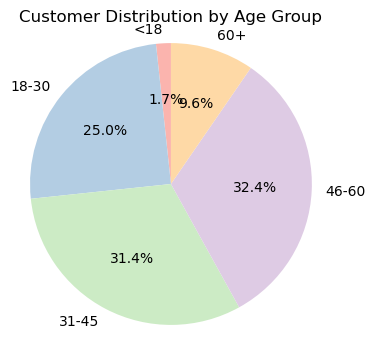

In [108]:
#1 Visualise the distribution of customers by age groups using a histogram or pie chart.
# Pie Chart
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18-30', '31-45', '46-60', '60+']
customer['age_group'] = pd.cut(customer['age'], bins=bins, labels=labels)

# Pie chart
age_counts = customer['age_group'].value_counts().sort_index()
plt.figure(figsize=(4, 4))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Customer Distribution by Age Group')
plt.axis('equal')
plt.show()

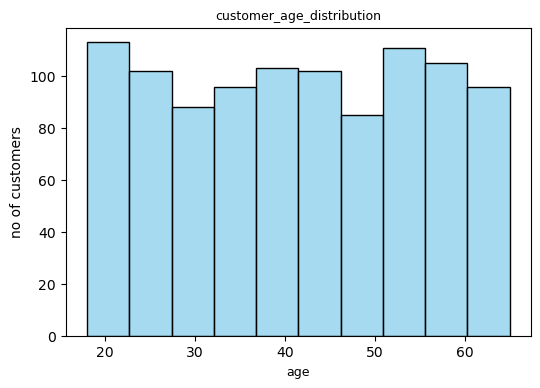

In [109]:
#creating an histogram 
plt.figure(figsize=(6,4))
sns.histplot(customer['age'],bins=10,kde=False,color='skyblue')
plt.title('customer_age_distribution',fontsize=9)
plt.xlabel('age',fontsize=9)
plt.ylabel('no of customers')
plt.show()

In [110]:
# 2 Identify the countries with the highest number of customers and visualize the distribution of customers across countries using a horizontal bar chart.
top_countries= customer['country'].value_counts().head(10)
top_countries

country
Colombia    280
Chile       255
Brazil      234
Mexico      232
Name: count, dtype: int64

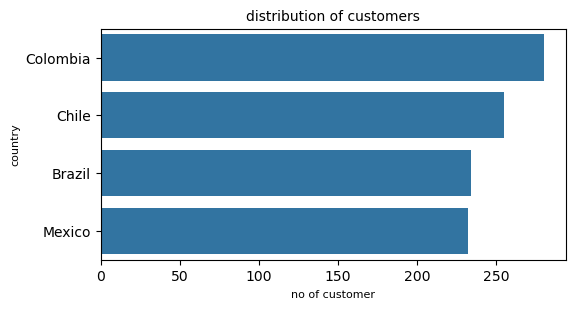

In [111]:
plt.figure(figsize=(6,3))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('distribution of customers',fontsize=10)
plt.xlabel('no of customer',fontsize=8)
plt.ylabel('country',fontsize=8)
plt.show()

Task 3: Shipping Cost Optimisation
1. Calculate the average shipping cost for orders that were shipped within 3 days vs.
orders shipped after 3 days.

In [154]:
#1 converting order and shipping date to datetime
purchase['order_date']= pd.to_datetime(purchase['order_date'],errors='coerce')
purchase['shipping_date']= pd.to_datetime(purchase['shipping_date'],errors='coerce')

In [155]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       50000 non-null  object        
 1   customer_id    50000 non-null  object        
 2   product_name   50000 non-null  object        
 3   description    50000 non-null  object        
 4   price          50000 non-null  float64       
 5   discount       50000 non-null  float64       
 6   tax            50000 non-null  float64       
 7   order_date     50000 non-null  datetime64[ns]
 8   quantity       50000 non-null  int64         
 9   shipping_cost  50000 non-null  float64       
 10  shipping_date  50000 non-null  datetime64[ns]
 11  revenue        50000 non-null  float64       
 12  shipping_days  50000 non-null  int64         
dtypes: datetime64[ns](2), float64(5), int64(2), object(4)
memory usage: 5.0+ MB


In [156]:
purchase['shipping_days']= (purchase['shipping_date']-purchase['order_date']).dt.days

In [157]:
purchase.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,revenue,shipping_days
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,2020-05-26,9,8.91,2020-05-29,5806.53,3
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,2022-12-29,9,13.95,2022-12-29,259.83,0
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,2021-03-06,3,36.42,2021-03-06,10608.96,0
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,2020-03-11,7,9.35,2020-03-13,684.39,2
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,2022-03-12,7,8.55,2022-03-15,12496.75,3


In [116]:
within_3_days= purchase[purchase['shipping_days']<=3]
after_3_days= purchase[purchase['shipping_days']>3]

In [117]:
avg_within_3 = within_3_days['shipping_cost'].mean()
avg_after_3 = after_3_days['shipping_cost'].mean()

In [118]:
print(f"Average Shipping Cost (≤ 3 days): ₹{avg_within_3:.2f}")
print(f"Average Shipping Cost (> 3 days): ₹{avg_after_3:.2f}")

Average Shipping Cost (≤ 3 days): ₹27.56
Average Shipping Cost (> 3 days): ₹27.49


# Compare the average income of male and female customers using a t-test.
● Null Hypothesis (H0): There is no significant difference in average income
between male and female customers.
● Alternate Hypothesis (H1): There is a significant difference in average
income between male and female customers.

In [127]:
import pandas as pd 
from scipy.stats import ttest_ind

In [128]:
male_customers = customer[customer['gender']=='Male']['income']

In [129]:
male_customers

1       49256
2       33434
3       75302
4       32280
6       46062
        ...  
991     59226
992     51519
993    137509
994    119039
998    129926
Name: income, Length: 506, dtype: int64

In [130]:
female_customers = customer[customer['gender']=='Female']['income']

In [131]:
female_customers

0       117196
5        86237
7        78878
8       119458
11       33396
         ...  
995     114917
996     117708
997      32803
999      99320
1000     23883
Name: income, Length: 495, dtype: int64

In [132]:
# perform ttest
t_stat,p_ttest= ttest_ind(male_customers,female_customers)

In [133]:
# print results
print('t.test results:')
print(f't_statistic:{t_stat:.3f}')
print(f'p_value:{p_ttest:.3f}')
if p_ttest<0.05:
    print('conclusion: reject the null hypothesis ,there is no significant difference in average income between male and female customers.')
else:
    print('conclusion:Fail to reject the null hypothesis,There is a significant difference in average income between male and female customers.')
    
    

t.test results:
t_statistic:-0.245
p_value:0.807
conclusion:Fail to reject the null hypothesis,There is a significant difference in average income between male and female customers.


#2. Determine if there is a significant association between product categories (derived from product_name) and customer gender using a Chi-Square test.

In [134]:
from scipy.stats import chi2_contingency

In [139]:
sheet_data=pd.merge(purchase,customer,on='customer_id',how='left')
sheet_data.head(4)

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,revenue,shipping_days,first_name,last_name,gender,age,country,income,age_group
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,2020-05-26,9,8.91,2020-05-29,5806.53,3,Isadora,Porto,Female,19,Brazil,117196,18-30
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,2022-12-29,9,13.95,2022-12-29,259.83,0,Hugo,Carreño,Male,33,Chile,49256,31-45
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,2021-03-06,3,36.42,2021-03-06,10608.96,0,René,Olivera,Male,65,Mexico,33434,60+
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,2020-03-11,7,9.35,2020-03-13,684.39,2,Luiz Henrique,Pinto,Male,55,Brazil,75302,46-60


In [142]:
# create contingency table
contingency_table = pd.crosstab(sheet_data['gender'],sheet_data['product_name'])
contingency_table

product_name,Activewear Set,Appliance Set,Bedding,Camera,Curtains,Dining Set,Dress,Formal Shirt,Furniture,Gaming Console,...,Smart Watch,Smartphone,Sports Shoes,Sweater,T-Shirt,TV,Tablet,Virtual Reality Headset,Wall Art,Wireless Speaker
gender,,,,,,,,,,,,,,,,,,,,,
Female,852,839,810,812,839,819,780,796,844,839,...,832,852,867,823,834,803,814,811,835,832
Male,855,824,833,873,856,775,798,843,851,847,...,831,837,896,841,881,871,859,813,872,885


In [144]:
# Calculating chi square test stats using chi2 contigency function.
chi2_stat,p_chi2,dof,expected= chi2_contingency(contingency_table)

In [146]:
# output results
print("\n Chi-Square Test Reults:")
print(f"Chi2-Statistic:{chi2_stat:.3f}")
print(f"p-value:{p_chi2:.3f}")
print(f"Degrees Of Freedom:{dof}")

if p_chi2 < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant association between product Category and gender.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No significant association between product Category and gender.")




 Chi-Square Test Reults:
Chi2-Statistic:22.593
p-value:0.795
Degrees Of Freedom:29
Conclusion: Fail to reject the null hypothesis. No significant association between product Category and gender.


Task 5: Correlation.
1. Calculate the correlation between customer income and the total cost of their
purchases

In [147]:
correlation = sheet_data['income'].corr(sheet_data['revenue'])

In [152]:
print('correlation')
print(f'correlation between customer income and total cost of their purhase is:{correlation:.4f}')

correlation
correlation between customer income and total cost of their purhase is:0.0031


In [153]:
# another method
sheetdata_numeric = sheet_data[['income', 'revenue']]

sheetdata_numeric.corr()

,income,revenue
income,1.000000,0.003121
revenue,0.003121,1.000000


### 🔍 **Business Recommendations from Sales & Customer Analysis**

1. Optimize Pricing & Shipping:**

 Reduce discounts slightly on top-selling products to boost margins.
 Promote faster shipping (within 3 days) as it's more cost-effective.
 Re-evaluate heavily discounted low-revenue items.

2. Target Customer Segments:**

 Focus marketing on top age groups (e.g., 18–30).
 Customize offers for countries with the most customers.
 Use age and region for email and ad personalization.

3. Maximize Profit from Top Products:**

 Invest in ads and inventory for top 5 revenue-generating products.
 Bundle top performers with slower-moving items.
 Expand product lines based on bestsellers' success.
